# Learn Probability Density Functions using Roll-Number-Parameterized Non-Linear Model

**Name:** Arun Mahajan  
**Roll No:** 102303346  
**Feature Used:** NO₂  

Steps:
1. Apply roll-number-based non-linear transformation
2. Estimate Gaussian-type PDF parameters using MLE
3. Visualize fitted distribution


Available columns:
Index(['stn_code', 'sampling_date', 'state', 'location', 'agency', 'type',
       'so2', 'no2', 'rspm', 'spm', 'location_monitoring_station', 'pm2_5',
       'date'],
      dtype='object')

Estimated Parameters:
mu = 25.81266175882587
lambda = 0.001460577420359888
c = 0.021561916251515552


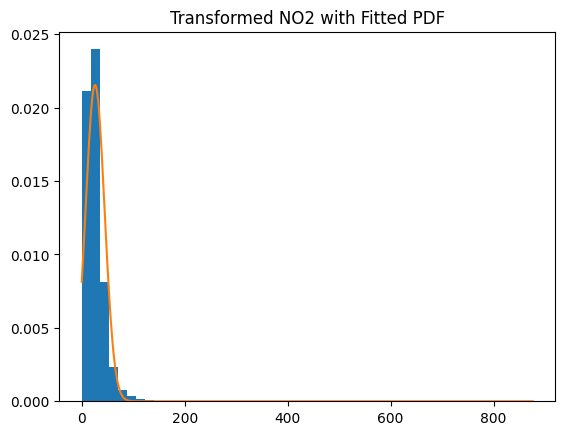

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset safely
df = pd.read_csv("/content/data.csv", encoding="latin1", low_memory=False)

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

print("Available columns:")
print(df.columns)

# Automatically find NO2 column (case insensitive)
no2_col = [col for col in df.columns if col.lower() == "no2"]

if len(no2_col) == 0:
    raise Exception("NO2 column not found. Check column names above.")
else:
    no2_col = no2_col[0]

# Extract NO2
x = pd.to_numeric(df[no2_col], errors="coerce").dropna().values

# Roll number
r = 102303346

a_r = 0.05 * (r % 7)
b_r = 0.3 * ((r % 5) + 1)

# Transformation
z = x + a_r * np.sin(b_r * x)

# Estimate parameters
mu = np.mean(z)
variance = np.var(z)

lam = 1 / (2 * variance)
c = 1 / np.sqrt(2 * np.pi * variance)

print("\nEstimated Parameters:")
print("mu =", mu)
print("lambda =", lam)
print("c =", c)

# Plot
plt.hist(z, bins=50, density=True)

z_vals = np.linspace(min(z), max(z), 500)
pdf = c * np.exp(-lam * (z_vals - mu)**2)

plt.plot(z_vals, pdf)
plt.title("Transformed NO2 with Fitted PDF")
plt.show()
